## Face and Facial Keypoint detection

After you've trained a neural network to detect facial keypoints, you can then apply this network to *any* image that includes faces. The neural network expects a Tensor of a certain size as input and, so, to detect any face, you'll first have to do some pre-processing.

1. Detect all the faces in an image using a face detector (we'll be using a Haar Cascade detector in this notebook).
2. Pre-process those face images so that they are grayscale, and transformed to a Tensor of the input size that your net expects. This step will be similar to the `data_transform` you created and applied in Notebook 2, whose job was tp rescale, normalize, and turn any iimage into a Tensor to be accepted as input to your CNN.
3. Use your trained model to detect facial keypoints on the image.

---

In the next python cell we load in required libraries for this section of the project.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import torch

from models import Net

%matplotlib inline

print("Imports loaded correctly")

Imports loaded correctly


In [2]:
from IPython.display import clear_output

plt.close('all')
clear_output(wait=True)

print("Outputs cleared")

Outputs cleared


#### Select an image 

Select an image to perform facial keypoint detection on; you can select any image of faces in the `images/` directory.

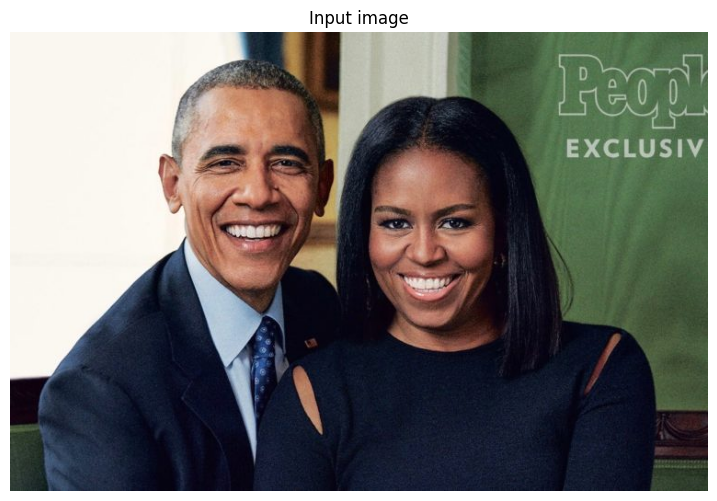

In [3]:
# Load image
image = cv2.imread('images/obamas.jpg')

if image is None:
    raise FileNotFoundError("Image not found. Check that images/obamas.jpg exists.")

# Convert BGR to RGB for matplotlib
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 9))
plt.imshow(image)
plt.title("Input image")
plt.axis("off")
plt.show()

## Detect all faces in an image

Next, you'll use one of OpenCV's pre-trained Haar Cascade classifiers, all of which can be found in the `detector_architectures/` directory, to find any faces in your selected image.

In the code below, we loop over each face in the original image and draw a red square on each face (in a copy of the original image, so as not to modify the original). You can even [add eye detections](https://docs.opencv.org/3.4.1/d7/d8b/tutorial_py_face_detection.html) as an *optional* exercise in using Haar detectors.

An example of face detection on a variety of images is shown below.

<img src='images/haar_cascade_ex.png' width=80% height=80%/>


Number of faces detected: 2
Faces: [[370 141 165 165]
 [174  71 180 180]]


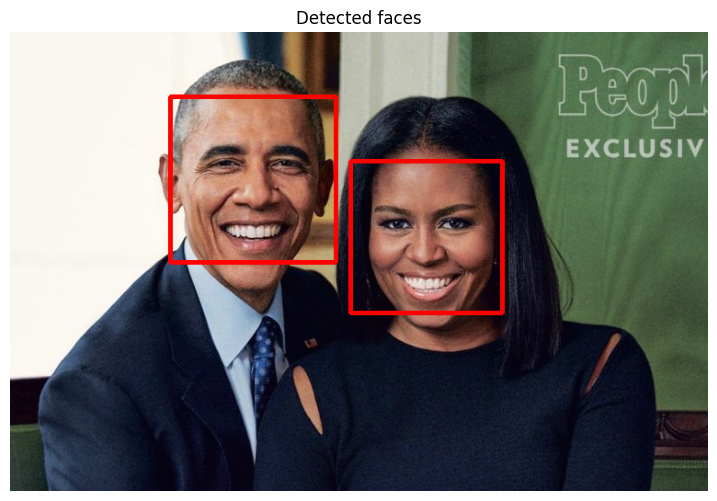

In [4]:
# Convert image to grayscale for Haar Cascade
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Load Haar Cascade classifier
face_cascade = cv2.CascadeClassifier(
    'detector_architectures/haarcascade_frontalface_default.xml'
)

if face_cascade.empty():
    raise FileNotFoundError("Haar cascade file not loaded correctly.")

# Detect faces
faces = face_cascade.detectMultiScale(
    gray_image,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(60, 60)
)

print("Number of faces detected:", len(faces))
print("Faces:", faces)

# Draw rectangles around detected faces
image_with_detections = np.copy(image)

for (x, y, w, h) in faces:
    cv2.rectangle(
        image_with_detections,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        3
    )

plt.figure(figsize=(9, 9))
plt.imshow(image_with_detections)
plt.title("Detected faces")
plt.axis("off")
plt.show()

In [5]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create model
net = Net()

# Load trained model parameters
net.load_state_dict(
    torch.load('saved_models/keypoints_model_1.pt', map_location=device)
)

# Move model to device
net.to(device)

# Evaluation mode
net.eval()

print("Model loaded successfully")


Using device: cuda
Model loaded successfully


In [6]:
def make_square_crop(image, x, y, w, h, padding_ratio=0.30):
    """
    Create a square crop around a detected face.
    """
    img_h, img_w = image.shape[:2]

    center_x = x + w // 2
    center_y = y + h // 2

    side = max(w, h)
    side = int(side * (1.0 + padding_ratio))

    x1 = int(center_x - side // 2)
    y1 = int(center_y - side // 2)
    x2 = int(center_x + side // 2)
    y2 = int(center_y + side // 2)

    x1 = max(x1, 0)
    y1 = max(y1, 0)
    x2 = min(x2, img_w)
    y2 = min(y2, img_h)

    crop = image[y1:y2, x1:x2]

    return crop, x1, y1, x2, y2

In [7]:
def make_square_crop(image, x, y, w, h, padding_ratio=0.30):
    """
    Create a square crop around a detected face.
    """
    img_h, img_w = image.shape[:2]

    center_x = x + w // 2
    center_y = y + h // 2

    side = max(w, h)
    side = int(side * (1.0 + padding_ratio))

    x1 = int(center_x - side // 2)
    y1 = int(center_y - side // 2)
    x2 = int(center_x + side // 2)
    y2 = int(center_y + side // 2)

    x1 = max(x1, 0)
    y1 = max(y1, 0)
    x2 = min(x2, img_w)
    y2 = min(y2, img_h)

    crop = image[y1:y2, x1:x2]

    return crop, x1, y1, x2, y2

## Loading in a trained model

Once you have an image to work with (and, again, you can select any image of faces in the `images/` directory), the next step is to pre-process that image and feed it into your CNN facial keypoint detector.

First, load your best model by its filename.

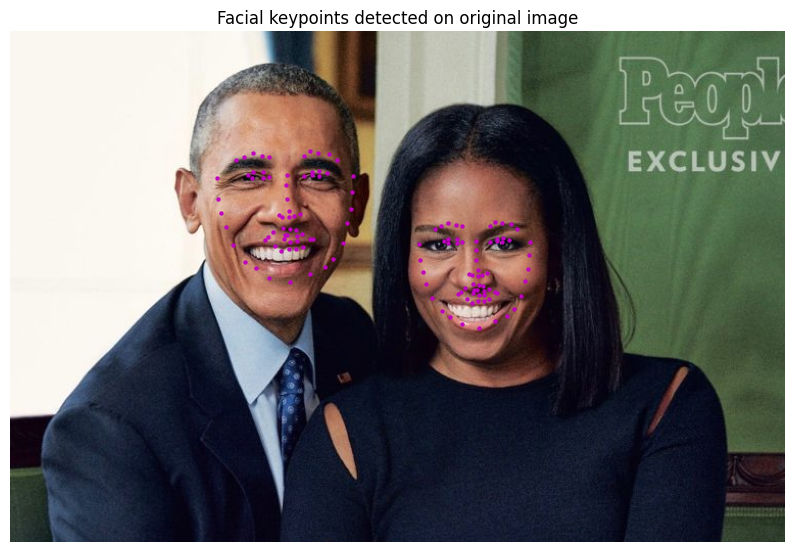

In [8]:
image_keypoints = np.copy(image)

plt.figure(figsize=(10, 10))
plt.imshow(image_keypoints)

for face_idx, (x, y, w, h) in enumerate(faces):

    roi, x1, y1, x2, y2 = make_square_crop(
        image_keypoints,
        x,
        y,
        w,
        h,
        padding_ratio=0.30
    )

    # Convert ROI to grayscale
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)

    # Normalize to [0, 1]
    roi_gray = roi_gray / 255.0

    crop_h, crop_w = roi_gray.shape

    # Resize to model input size
    roi_resized = cv2.resize(roi_gray, (224, 224))

    # Convert to tensor
    roi_tensor = torch.from_numpy(roi_resized).float()
    roi_tensor = roi_tensor.unsqueeze(0).unsqueeze(0)
    roi_tensor = roi_tensor.to(device)

    # Predict
    with torch.no_grad():
        output_pts = net(roi_tensor)

    output_pts = output_pts.view(68, 2).cpu().numpy()

    # Undo normalization
    output_pts = output_pts * 50.0 + 100.0

    # Scale from 224x224 to crop size
    output_pts[:, 0] = output_pts[:, 0] * crop_w / 224.0
    output_pts[:, 1] = output_pts[:, 1] * crop_h / 224.0

    # Move from crop coordinates to full image coordinates
    output_pts[:, 0] += x1
    output_pts[:, 1] += y1

    # Draw keypoints on original image
    plt.scatter(
        output_pts[:, 0],
        output_pts[:, 1],
        s=18,
        marker='.',
        c='m'
    )

plt.title('Facial keypoints detected on original image')
plt.axis('off')
plt.show()

## Keypoint detection

Now, we'll loop over each detected face in an image (again!) only this time, you'll transform those faces in Tensors that your CNN can accept as input images.

### TODO: Transform each detected face into an input Tensor

You'll need to perform the following steps for each detected face:
1. Convert the face from RGB to grayscale
2. Normalize the grayscale image so that its color range falls in [0,1] instead of [0,255]
3. Rescale the detected face to be the expected square size for your CNN (224x224, suggested)
4. Reshape the numpy image into a torch image.

**Hint**: The sizes of faces detected by a Haar detector and the faces your network has been trained on are of different sizes. If you find that your model is generating keypoints that are too small for a given face, try adding some padding to the detected `roi` before giving it as input to your model.

You may find it useful to consult to transformation code in `data_load.py` to help you perform these processing steps.


### TODO: Detect and display the predicted keypoints

After each face has been appropriately converted into an input Tensor for your network to see as input, you can apply your `net` to each face. The ouput should be the predicted the facial keypoints. These keypoints will need to be "un-normalized" for display, and you may find it helpful to write a helper function like `show_keypoints`. You should end up with an image like the following with facial keypoints that closely match the facial features on each individual face:

<img src='images/michelle_detected.png' width=30% height=30%/>




In [12]:
print("Notebook 3 completed successfully.")
print("Number of faces detected:", len(faces))
print("Model used: saved_models/keypoints_model_1.pt")

Notebook 3 completed successfully.
Number of faces detected: 2
Model used: saved_models/keypoints_model_1.pt
